### General Imports:


In [ ]:
import os
import gym
from stable_baselines3.ppo import PPO
from stable_baselines3.ppo.policies import MlpPolicy as MLP_PPO
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import seaborn as sns
from netsim.gym_basic.envs import RMSA_ENV
from netsim.netSimPy import *
from sklearn import tree
from stable_baselines3.common.callbacks import EvalCallback
import numpy as np
import tensorflow as tf
import logging
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

logging.getLogger("tensorflow").setLevel(logging.FATAL)
tf.__version__
from stable_baselines3.common.vec_env import (
    DummyVecEnv,
    is_vecenv_wrapped,
)

/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/jbcedeno/Documents/netsim/.netsim_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def warming_lr(initial_lr=1.5e-4, max_warm_lr=3e-4, final_lr=2e-4, warmup_progress=0.85):
    def learning_rate_fn(progress):
        if progress >= warmup_progress:
            m = (initial_lr - max_warm_lr) / (1 - warmup_progress)
            n = initial_lr - m
            return round(m * progress + n, 6)
        else:
            m = (max_warm_lr - final_lr) / warmup_progress
            return round(m * progress + final_lr, 6)

    return learning_rate_fn

In [ ]:
from typing import Union, Optional


class MyBestCallback(EvalCallback):
    def __init__(
        self,
        eval_env: RMSA_ENV,
        callback_on_new_best=None,
        callback_after_eval=None,
        n_eval_episodes: int = 5,
        eval_freq: int = 10000,
        log_path: Optional[str] = None,
        best_model_save_path: Optional[str] = None,
        deterministic: bool = True,
        render: bool = False,
        verbose: int = 1,
        warn: bool = True,
    ):
        super().__init__(
            eval_env,
            callback_on_new_best,
            callback_after_eval,
            n_eval_episodes,
            eval_freq,
            log_path,
            best_model_save_path,
            deterministic,
            render,
            verbose,
            warn,
        )
        self.eval_env = eval_env
        self.best_reward_at = 0

    def _on_step(self) -> bool:
        continue_training = True

        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            # Sync training and eval env if there is VecNormalize
            if self.model.get_vec_normalize_env() is not None:
                try:
                    sync_envs_normalization(self.training_env, self.eval_env)
                except AttributeError as e:
                    raise AssertionError(
                        "Training and eval env are not wrapped the same way, "
                        "see https://stable-baselines3.readthedocs.io/en/master/guide/callbacks.html#evalcallback "
                        "and warning above."
                    ) from e

            # Reset success rate buffer
            self._is_success_buffer = []
            # self.eval_env.reset(hard_reset=True)
            episode_rewards, episode_lengths = evaluate_policy(
                self.model,
                self.eval_env,
                n_eval_episodes=self.n_eval_episodes,
                render=self.render,
                deterministic=self.deterministic,
                return_episode_rewards=True,
                warn=self.warn,
                callback=self._log_success_callback,
            )

            if self.log_path is not None:
                self.evaluations_timesteps.append(self.num_timesteps)
                self.evaluations_results.append(episode_rewards)
                self.evaluations_length.append(episode_lengths)

                kwargs = {}
                # Save success log if present
                if len(self._is_success_buffer) > 0:
                    self.evaluations_successes.append(self._is_success_buffer)
                    kwargs = dict(successes=self.evaluations_successes)

                np.savez(
                    self.log_path,
                    timesteps=self.evaluations_timesteps,
                    results=self.evaluations_results,
                    ep_lengths=self.evaluations_length,
                    **kwargs,
                )

            mean_reward, std_reward = np.mean(episode_rewards), np.std(episode_rewards)
            mean_ep_length, std_ep_length = np.mean(episode_lengths), np.std(
                episode_lengths
            )
            self.last_mean_reward = mean_reward

            if self.verbose >= 1:
                print(
                    f"Eval num_timesteps={self.num_timesteps}, "
                    f"episode_reward={mean_reward:.2f} +/- {std_reward:.2f}"
                )
            # Add to current Logger
            self.logger.record("eval/mean_reward", float(mean_reward))
            self.logger.record("eval/mean_ep_length", mean_ep_length)

            if len(self._is_success_buffer) > 0:
                success_rate = np.mean(self._is_success_buffer)
                if self.verbose >= 1:
                    print(f"Success rate: {100 * success_rate:.2f}%")
                self.logger.record("eval/success_rate", success_rate)

            # Dump log so the evaluation results are printed with the correct timestep
            self.logger.record(
                "time/total_timesteps", self.num_timesteps, exclude="tensorboard"
            )
            self.logger.dump(self.num_timesteps)

            if mean_reward > self.best_mean_reward:
                self.best_reward_at = self.num_timesteps
                if self.best_model_save_path is not None:
                    self.model.save(os.path.join(self.best_model_save_path, "best_model"))
                self.best_mean_reward = mean_reward
                # Trigger callback on new best model, if needed
                if self.callback_on_new_best is not None:
                    continue_training = self.callback_on_new_best.on_step()
            print(
                f"Best mean reward: {self.best_mean_reward:.2f} at timestep No. {self.best_reward_at}"
            )
            clear_output(wait=True)
            # Trigger callback after every evaluation, if needed
            if self.callback is not None:
                continue_training = continue_training and self._on_event()

        return continue_training

In [ ]:
from netsim.allocators import sap_ff

# FILES AND DIRECTORIES:
__file__ = "RMSA.ipynb"
absolutepath = os.path.abspath(__file__)
file_name = os.path.basename(os.path.abspath(__file__)).split(".")[0]
fileDirectory = os.path.dirname(os.path.dirname(os.getcwd())) + "/notebooks/networks"
log_dir = f"./tmp/{file_name}/"
os.makedirs(log_dir, exist_ok=True)
tensorboard_log = f"./tb/{file_name}/nsfnet/"

# SIMULATION PARAMS:
# TOTAL_TIMESTEPS = int(12e6)
TOTAL_TIMESTEPS = int(4e6)
EPISODE_LENGTH = 1000
N_EVALUATION_EPISODES = 80
# EVAL_FREQ = N_EVALUATION_EPISODES * EPISODE_LENGTH
EVAL_FREQ = 50000
N_BLOCKS = 5
N_PATHS = 3
M_LAMBDA = 5000

network = Network(
    networkFileName=fileDirectory + "/RMSA_NSFNet.json",
    pathsFileName=fileDirectory + "/RMSA_NSFNet_routes.json",
    bitrateFilename=fileDirectory + "/RMSA_NSFNet_bitrate.json",
)
generator = EventsGenerator(mLambda=M_LAMBDA)
env_args = dict(
    network=network,
    eventsGenerator=generator,
    j=N_BLOCKS,
    n_paths=N_PATHS,
    episode_length=EPISODE_LENGTH,
)
env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir)

# MODEL HYPERPARAMETERS:
mArgs = dict(
    # learning_rate=warming_lr(warmup_progress = 0.95),
    # clip_range = 0.1,
    # n_steps= 2048,
    gamma=0.9,
    # ent_coef= 0.01,
    # n_epochs=23,
    # batch_size = 512,
    # ent_coef= 0.0015,
    # n_epochs=27,
    # n_steps= 1024,
    # gamma= 0.95,
    # batch_size = 16,
)
# model = PPO(MLP_PPO, env, verbose=0, seed=3, tensorboard_log=tensorboard_log, **mArgs)
model = PPO(MLP_PPO, env, verbose=0, seed=3, tensorboard_log=tensorboard_log, **mArgs)

# env.setAllocatorFunc(sap_ff)
# callback = CustomCallback(env, eval_freq=EVAL_FREQ, n_eval_episodes=N_EVALUATION_EPISODES, verbose=0, log_path=log_dir)
eval_env: RMSA_ENV = Monitor(gym.make("RMSA_ENV-v0", **env_args), log_dir + "eval_env")
# best_model_save_path = os.path.join(log_dir, "best_model")
callback = MyBestCallback(
    eval_env,
    n_eval_episodes=N_EVALUATION_EPISODES,
    eval_freq=EVAL_FREQ,
    log_path=log_dir,
    best_model_save_path=log_dir,
    verbose=1,
)
# train_model = model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
best_model_dir = f"./tmp/RMSA/best_model.zip"
expert = PPO.load(best_model_dir)

In [ ]:
def generate_trajectories(n_timesteps, model, env, only_accepted=True):
    trajectories = []
    timesteps_count = 0
    state = None
    done = False
    observation = env.reset()

    while timesteps_count < n_timesteps:
        act, state = model.predict(
            observation,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        traj = {"obs": observation, "action": act}
        observation, reward, done, info = env.step(act)
        traj["reward"] = reward
        if only_accepted:
            if reward > 0:
                trajectories.append(traj)
                timesteps_count += 1
        else:
            trajectories.append(traj)
            timesteps_count += 1
        if done:
            env.reset()
    return trajectories


def flatten_trajectories(traj):
    obs = [t["obs"] for t in traj]
    acts = [t["action"] for t in traj]
    rewards = [t["reward"] for t in traj]
    return obs, acts, rewards


class MixerPolicy:
    def __init__(self, expert, student, beta):
        self.student = student
        self.expert = expert
        self.beta = beta

    def set(self, expert, student, beta):
        self.student = student
        self.expert = expert
        self.beta = beta

    def predict(self, observation, state, episode_start, deterministic):
        model = np.random.choice(["A", "B"], p=[self.beta, 1 - self.beta])
        if model == "A":
            return self.expert.predict(observation, state, episode_start, deterministic)
        else:
            return self.student.predict([observation])[0], None


def get_expert_acts(expert, obs, env):
    acts = []
    state = None
    done = False
    env.reset()
    for o in obs:
        act, state = expert.predict(
            o,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        acts.append(act)
    return acts


def linear_beta(start, end, steps):
    def call(n):
        return max(start + n * (end - start) / (steps - 1), end)

    return call

In [ ]:
from sklearn import ensemble
from sklearn import tree
from IPython.display import clear_output
import pickle as pkl
import pandas as pd
import json


def decode_action(act, j):
    idx_path = act // j
    idx_block = act % j
    return idx_path, idx_block


def get_route_from_action(acts, j):
    return [decode_action(a, j)[0] for a in acts]


def evaluate_student(student, n_timesteps):
    traj = generate_trajectories(n_timesteps, expert, env)
    x_test = [t["obs"] for t in traj]
    y_test = [t["action"] for t in traj]
    # y_test =  get_route_from_action(y_test, env.j)
    y_pred = student.predict(x_test)

    conf_matrix = confusion_matrix(y_test, y_pred)
    score = accuracy_score(y_test, y_pred)
    print(score, conf_matrix)


def train_with_dagger(
    expert,
    env,
    beta_func,
    n_rounds,
    timesteps_by_round,
    on_round_change=None,
    trajes_output_name=file_name + "_trajs.csv",
):
    student_policy = tree.DecisionTreeClassifier()
    print(f"Starting round 1")
    print(f"Sampling new trajectories for round: {1} ")
    obs, acts, _rewards = flatten_trajectories(
        generate_trajectories(timesteps_by_round, expert, env)
    )

    # routes = get_route_from_action(acts, env.j)
    student_policy.fit(obs, acts)
    evaluate_student(student_policy, 100000)

    for r in range(1, n_rounds):
        print(f"Starting round {r+1}")
        mixer = MixerPolicy(expert, student_policy, beta=beta_func(r))
        print(f"Sampling new trajectories for round: {r+1} ")
        obs2, _acts, _rewards = flatten_trajectories(
            generate_trajectories(timesteps_by_round, mixer, env)
        )
        acts2 = get_expert_acts(expert, obs2, env)

        # extend and update:
        shuffle = np.arange(len(obs2))
        np.random.shuffle(shuffle)
        obs2 = [obs2[s] for s in shuffle]
        acts2 = [acts2[s] for s in shuffle]
        obs.extend(obs2)
        acts.extend(acts2)

        # print(f"Saving trajectories for round: {r+1} ")
        # df = pd.DataFrame({'x':[json.dumps(o.tolist(),separators=(',', ':')) for o in obs2], 'y':acts2})
        # df.to_csv(trajes_output_name,
        #             mode="a",
        #             index=False,
        #             header=False
        #         )
        print(f"Fitting student for round: {r+1} ")
        # clear_output(wait=True)

        # routes = get_route_from_action(acts, env.j)
        student_policy.fit(obs, acts)
        evaluate_student(student_policy, 100000)

    return student_policy

In [ ]:
n_steps = 8
beta_func = linear_beta(1, 0, n_steps)
student = train_with_dagger(expert, env, beta_func, n_steps, timesteps_by_round=70000)

Starting round 1
Sampling new trajectories for round: 1 
0.73727 [[46586   783   619     1     0  1321   731   327     3  1314   120   792
    108]
 [  740  2713   547     0     1   636   132    14     0   243    55   112
     44]
 [  611   557  2817     1     0   813   233    29     0   276    88   204
     11]
 [    0     0     0     0     0     1     0     0     0     0     0     0
      0]
 [    1     0     0     0     1     0     0     0     0     0     0     0
      0]
 [ 1301   601   757     0     0  8642   452   204     0   954   101   171
    205]
 [  667   120   232     0     0   440  2736   128     0   322   244   271
     42]
 [  429     9    24     0     0   207   115   868     0    61    69    73
     40]
 [    4     0     0     0     0     0     0     0     0     0     0     0
      0]
 [ 1211   254   295     0     0   905   317    61     0  4967    47    44
     33]
 [  144    55    97     0     0   106   250    69     0    46  1328   208
      5]
 [  720    90   190   

### Saving the agent


In [ ]:
pickle_out = open("student_DT.pkl", "wb")
pkl.dump(student, pickle_out)
pickle_out.close()
# pickle_out = open("student_DT.pkl","rb")
# student = pkl.load(pickle_out)
# pickle_out.close()

In [ ]:
def get_actions_count(y_test):
    y1_test = [0] * 15
    for yv in y_test:
        y1_test[yv] += 1
    return y1_test

### Global accuracy


In [ ]:
traj = generate_trajectories(200000, expert, env)
x_test = [t["obs"] for t in traj]
y_test = [int(t["action"]) for t in traj]

# y_pred = predict(x_test,student, env)
y_pred = student.predict(x_test)
score = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred, labels=[i for i in range(15)])
print(score)
print(conf_matrix)
print(f1_score(y_test, y_pred, average="weighted"))

0.785195
[[95715  1262  1020     5     2  2024  1099   677     1     0  2090   217
   1242   172     0]
 [ 1247  6517   859     5     1  1020   212    25     0     0   430   140
    166    69     0]
 [  983   915  6433     1     3  1377   445    38     0     0   437   135
    300    22     0]
 [    3     1     1     1     0     0     0     0     0     0     1     0
      0     0     0]
 [    0     0     2     0     0     0     0     0     0     0     0     0
      1     1     0]
 [ 2072  1055  1396     1     0 18965   687   333     2     0  1607   174
    274   371     0]
 [  999   206   366     0     0   714  6267   218     2     1   555   381
    358    55     0]
 [  593    30    51     0     0   366   185  2081     3     0   110   130
    128    57     0]
 [    2     0     0     0     0     1     3     0     0     0     0     0
      0     0     0]
 [    0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0]
 [ 1996   452   446     0     0  1562   5

In [21]:
get_metrics(conf_matrix)

Clase 1:
  Precision: 0.9236
  F1-score: 0.9225
  Sensibilidad (Recall): 0.9213
  Especificidad: 11.7136

Clase 2:
  Precision: 0.6702
  F1-score: 0.6733
  Sensibilidad (Recall): 0.6764
  Especificidad: 2.0902

Clase 3:
  Precision: 0.6408
  F1-score: 0.6414
  Sensibilidad (Recall): 0.6419
  Especificidad: 1.7928

Clase 4:
  Precision: 0.5782
  F1-score: 0.5884
  Sensibilidad (Recall): 0.5990
  Especificidad: 1.4937

Clase 5:
  Precision: 0.0000
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000



/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_79542/2585605376.py:6: RuntimeWarning: invalid value encountered in divide
  f1_score = 2 * (precision * recall) / (precision + recall)


### Inter-path accuracy


In [ ]:
n_conf_matrix = np.zeros(shape=(3, 3))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n_conf_matrix[ir // 5, ic // 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n_conf_matrix)
print(s[0])
print(n_conf_matrix)

0.837065
[[114976.   6918.   5423.]
 [  6771.  29828.   4200.]
 [  5224.   4051.  22609.]]


In [ ]:
def get_metrics(matrix):
    # Calcula métricas
    precision = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=0)
    recall = np.diag(confusion_matrix) / np.sum(confusion_matrix, axis=1)
    specificity = np.diag(confusion_matrix) / (
        np.sum(confusion_matrix, axis=1) - np.diag(confusion_matrix)
    )
    f1_score = 2 * (precision * recall) / (precision + recall)

    # Imprime las métricas
    for i in range(len(precision)):
        print(f"Clase {i + 1}:")
        print(f"  Precision: {precision[i]:.4f}")
        print(f"  F1-score: {f1_score[i]:.4f}")
        print(f"  Sensibilidad (Recall): {recall[i]:.4f}")
        print(f"  Especificidad: {specificity[i]:.4f}\n")


# Matriz de confusión proporcionada
confusion_matrix = np.array(n_conf_matrix)

get_metrics(confusion_matrix)

Clase 1:
  Precision: 0.9055
  F1-score: 0.9043
  Sensibilidad (Recall): 0.9031
  Especificidad: 9.3166

Clase 2:
  Precision: 0.7311
  F1-score: 0.7311
  Sensibilidad (Recall): 0.7311
  Especificidad: 2.7188

Clase 3:
  Precision: 0.7014
  F1-score: 0.7053
  Sensibilidad (Recall): 0.7091
  Especificidad: 2.4376



### Inter-spectrum accuracy


In [ ]:
n2_conf_matrix = np.zeros(shape=(5, 5))
for ir, row in enumerate(conf_matrix):
    for ic, col in enumerate(row):
        n2_conf_matrix[ir % 5, ic % 5] += conf_matrix[ir][ic]


def score(matrix):
    total = sum(matrix.reshape(-1, 1))
    correct = np.trace(matrix)
    return correct / total


s = score(n2_conf_matrix)
print(s[0])
print(n2_conf_matrix)

0.85377
[[1.37119e+05 5.54000e+03 5.56100e+03 6.03000e+02 2.00000e+00]
 [5.44200e+03 1.72800e+04 2.68000e+03 1.43000e+02 2.00000e+00]
 [5.33900e+03 2.83700e+03 1.50420e+04 2.11000e+02 3.00000e+00]
 [5.63000e+02 1.27000e+02 1.88000e+02 1.31300e+03 1.00000e+00]
 [0.00000e+00 0.00000e+00 3.00000e+00 1.00000e+00 0.00000e+00]]


In [15]:
# Matriz de confusión proporcionada
confusion_matrix = np.array(n2_conf_matrix)

get_metrics(confusion_matrix)

Clase 1:
  Precision: 0.9236
  F1-score: 0.9225
  Sensibilidad (Recall): 0.9213
  Especificidad: 11.7136

Clase 2:
  Precision: 0.6702
  F1-score: 0.6733
  Sensibilidad (Recall): 0.6764
  Especificidad: 2.0902

Clase 3:
  Precision: 0.6408
  F1-score: 0.6414
  Sensibilidad (Recall): 0.6419
  Especificidad: 1.7928

Clase 4:
  Precision: 0.5782
  F1-score: 0.5884
  Sensibilidad (Recall): 0.5990
  Especificidad: 1.4937

Clase 5:
  Precision: 0.0000
  F1-score: nan
  Sensibilidad (Recall): 0.0000
  Especificidad: 0.0000



/var/folders/k2/q0rx2fz13mn6n61q8bpqwxtm0000gn/T/ipykernel_79542/2585605376.py:6: RuntimeWarning: invalid value encountered in divide
  f1_score = 2 * (precision * recall) / (precision + recall)


In [ ]:
def evaluate_bp_student(student, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.setLambda(mLambda)
    observation = env.reset()
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        act = student.predict([observation])[0]
        observation, reward, done, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps


def evaluate_expert(expert, n_timesteps, mLambda):
    timesteps_count = 0
    state = None
    done = False
    env.setLambda(mLambda)
    observation = env.reset()
    accepted_requests = 0

    while timesteps_count < n_timesteps:
        act, state = expert.predict(
            observation,
            state=state,
            episode_start=done,
            deterministic=True,
        )
        observation, reward, done, info = env.step(act)
        if reward == 1:
            accepted_requests += 1
        if done:
            env.reset()
        timesteps_count += 1
    return 1 - accepted_requests / n_timesteps


loads = [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]
results = {
    "model": [],
    "student": [],
}
N_EVALUATIONS = 400000

for l in loads:
    env.setAllocatorFunc(None)
    # agent_model, _ = evaluate_policy(env, n_eval_episodes=N_EVALUATION_EPISODES, model = model, return_dataframe=False, return_episode_rewards=False, seed=1)
    bp = evaluate_expert(expert, N_EVALUATIONS, l)
    print("model", bp)
    results["model"].append(bp)

    bp = evaluate_bp_student(student, N_EVALUATIONS, l)
    print("student", bp)
    results["student"].append(bp)

model 2.5000000000052758e-05
student 7.00000000000145e-05
model 9.00000000000345e-05
student 0.00011749999999999261
model 9.499999999995623e-05
student 0.00015750000000003261
model 0.00017500000000003624
student 0.00025249999999998884
model 0.00031000000000003247
student 0.0003575000000000106
model 0.0004275000000000251
student 0.0005150000000000432


In [ ]:
loads = [1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]
N_EVALUATIONS = 2000000
dt_bp = []

for l in loads:
    bp = evaluate_bp_student(student, N_EVALUATIONS, l)
    dt_bp.append(round(bp, 7))
print(dt_bp)

[5.9e-05, 0.00021, 0.0005335, 0.001161, 0.002236, 0.003819, 0.0058945, 0.0083745]


### features importance


[8.77145981e-04 1.05818260e-03 8.44241516e-04 8.71217141e-04
 9.00077037e-04 8.22015459e-04 7.42924811e-04 6.39607341e-04
 4.45350433e-04 1.21429141e-04 7.50682790e-05 6.69185325e-05
 8.70047090e-06 0.00000000e+00 0.00000000e+00 1.92386392e-04
 2.61703243e-04 6.10661464e-04 8.18973733e-04 7.57586387e-04
 7.93392405e-04 6.74713140e-04 8.39618645e-04 6.09176882e-04
 9.03947150e-04 6.99722313e-04 7.81833697e-04 6.87751048e-04
 1.68701453e-02 1.10485119e-02 2.36046672e-02 1.68784521e-02
 3.59902506e-02 2.12021274e-02 2.06143922e-02 2.04575023e-02
 1.72431580e-02 1.15499405e-02 1.91861809e-03 1.48648403e-02
 4.12747274e-02 2.06045224e-02 1.62346617e-02 3.41585598e-02
 1.90595936e-02 1.68291510e-02 4.97562329e-02 2.56446737e-02
 2.61006742e-02 1.37297442e-02 1.15752156e-02 2.51501549e-03
 1.64744986e-02 1.86271664e-02 3.01722655e-02 1.04798468e-02
 3.50981231e-02 2.59286575e-02 3.97203903e-02 3.86668157e-02
 2.26725947e-02 2.95069865e-02 2.59542231e-02 1.29048675e-02
 1.55843345e-01 1.646689

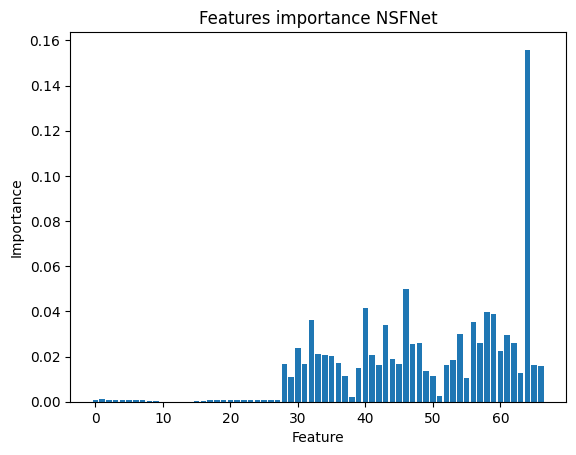

In [ ]:
import pandas as pd

base_output_dir_features = f"./plots/{__file__}/features_importance_heuristic/"

output_dir = base_output_dir_features
os.makedirs(output_dir, exist_ok=True)

# print("lolo",student.coef_[0])
# print("lolo",len(student.get_params()))

importances_sk = student.feature_importances_
importance = pd.DataFrame(importances_sk)
importance.to_csv(f"{output_dir}features_importance_heuristic.csv")
print(importances_sk)
plt.figure()
plt.bar([x for x in range(len(importances_sk))], importances_sk)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title(f"Features importance NSFNet")
plt.savefig(output_dir + "NSFNet.png")
plt.show()